# Task 4 - Step 0: Prepare CIFAR-10 and fix the protocol

* Decodes CIFAR-10 (Hugging Face mirror `uoft-cs/cifar10`, checksums recorded) into uint8 tensors [N,3,32,32]
  cached under `data/cifar/` (git-ignored).
* Creates the **stratified 90/10 split of the official training partition** (seed 6304): the training portion is
  the only data optimised on, the validation portion selects checkpoints **and** the rejection thresholds.
* Records the fixed near/far unknown class lists and the CIFAR-100 test parquet checksum.

**No CIFAR-100 image is decoded, loaded or shown here.** The unknown images are only decoded in notebook 03, after
the freeze manifest is written, through `task4.data.cifar100_unknowns.load_unknowns(...)`. Only the CIFAR-100
**test** split was downloaded; the training parquet was never fetched.

In [1]:
# ---- Task 4 common header (identical in every Task 4 notebook) ----
# NOTE: no CIFAR-100 image is decoded or loaded anywhere except notebook 03, after the freeze check.
import json, os, sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
while not (REPO / "task4" / "training.py").exists():
    if REPO.parent == REPO:
        raise RuntimeError("Run this notebook from inside the PA1 repository")
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from shared.config import load_config
from task4.data import cifar10
from task4.models.resnet_cifar import build_model

T4 = REPO / "task4"
CFG_DIR = T4 / "configs"
SEED = 6304
# Smoke mode (env TASK4_SMOKE=1): 2 epochs on 2000 training images; outputs under _smoke/; notebook 03 uses
# RANDOM stand-in "unknown" images, so no CIFAR-100 image is touched.
SMOKE = os.environ.get("TASK4_SMOKE", "0") == "1"
SUB = "_smoke" if SMOKE else ""
RES = T4 / "results" / SUB
TAB, FIG = RES / "tables", RES / "figures"
DATA_TAB = T4 / "results" / "tables"       # data-preparation files (same path in smoke and real mode)
DATA_TAB.mkdir(parents=True, exist_ok=True)
CKPT = T4 / "checkpoints" / SUB            # git-ignored
CACHE = T4 / "cache" / SUB                 # git-ignored
for p in [TAB, FIG, CKPT, CACHE]:
    p.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

RUNS = ["vanilla", "gcsc", "proser"]
LABEL = {"vanilla": "Vanilla", "gcsc": "GCSC", "proser": "PROSER"}
SCORES = ["msp", "mls", "energy", "mahalanobis"]         # post-hoc scores on the frozen Vanilla model
SCORE_LABEL = {"msp": "MSP", "mls": "MLS", "energy": "Energy", "mahalanobis": "Mahalanobis",
               "placeholder": "PROSER placeholder"}


def run_dir(n):
    return CKPT / load_config(CFG_DIR, n)["run_name"]


def load_trained(n):
    """Frozen model with the selected checkpoint of run ``n``."""
    cfg = load_config(CFG_DIR, n)
    ck = torch.load(run_dir(n) / "best.pt", map_location="cpu", weights_only=False)
    model = build_model(cfg["model"]["num_classes"], cfg["model"]["dummy_classifiers"], cfg["seed"])
    model.load_state_dict(ck["model"])
    return model.to(DEVICE).eval(), ck, cfg


@torch.no_grad()
def extract(model, x_u8, batch_size=512):
    """Penultimate features and logits of a frozen model (no augmentation)."""
    feats, logits = [], []
    for s in range(0, len(x_u8), batch_size):
        f, z = model(cifar10.normalize(x_u8[s:s + batch_size].to(DEVICE)))
        feats.append(f.float().cpu()); logits.append(z.float().cpu())
    return torch.cat(feats), torch.cat(logits)


plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "legend.fontsize": 9, "savefig.dpi": 150})


def savefig(fig, stem):
    fig.savefig(FIG / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{stem}.pdf", bbox_inches="tight")
    print("saved figure", stem)


print("REPO:", REPO, "| device:", DEVICE, "| smoke:", SMOKE)

REPO: C:\Users\afifh\Desktop\ATML\PA1 | device: cuda | smoke: False


In [2]:
summary = cifar10.prepare()
split = cifar10.make_split()
CLASSES = summary["classes"]
print("CIFAR-10 classes:", CLASSES)
print("train", summary["train"]["n"], "test", summary["test"]["n"], "| split:", split["n_train"], "/", split["n_val"])
xtr, ytr = cifar10.load("train"); xva, yva = cifar10.load("val"); xte, yte = cifar10.load("test")
counts = pd.DataFrame({"train": np.bincount(ytr.numpy(), minlength=10), "val": np.bincount(yva.numpy(), minlength=10),
                       "test": np.bincount(yte.numpy(), minlength=10)}, index=CLASSES)
assert len(set(split["train_idx"]) & set(split["val_idx"])) == 0
counts

CIFAR-10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train 50000 test 10000 | split: 45000 / 5000


,train,val,test
airplane,4500,500,1000
automobile,4500,500,1000
bird,4500,500,1000
cat,4500,500,1000
deer,4500,500,1000
dog,4500,500,1000
frog,4500,500,1000
horse,4500,500,1000
ship,4500,500,1000
truck,4500,500,1000


In [3]:
from task4.data import cifar100_unknowns as unk
data_summary = {"cifar10": {k: summary[k] for k in ("train", "test")}, "classes": CLASSES,
                "split": {"seed": split["seed"], "n_train": split["n_train"], "n_val": split["n_val"],
                          "file": "task4/results/tables/task4_cifar10_split.json"},
                "unknown_classes": {"near": unk.NEAR, "far": unk.FAR},
                "cifar100_test_parquet_sha256": cifar10.file_sha256(cifar10.DATA / "cifar100_test.parquet"),
                "cifar100_train_downloaded": (cifar10.DATA / "cifar100_train.parquet").exists(),
                "note": "CIFAR-100 images are not decoded until notebook 03 (after the freeze)."}
(DATA_TAB / "task4_data_summary.json").write_text(json.dumps(data_summary, indent=1))
counts.to_csv(DATA_TAB / "task4_cifar10_class_counts.csv")
print(json.dumps({k: v for k, v in data_summary.items() if k != "cifar10"}, indent=1))

{
 "classes": [
  "airplane",
  "automobile",
  "bird",
  "cat",
  "deer",
  "dog",
  "frog",
  "horse",
  "ship",
  "truck"
 ],
 "split": {
  "seed": 6304,
  "n_train": 45000,
  "n_val": 5000,
  "file": "task4/results/tables/task4_cifar10_split.json"
 },
 "unknown_classes": {
  "near": [
   "bus",
   "pickup_truck",
   "motorcycle",
   "tractor",
   "wolf",
   "fox",
   "leopard",
   "camel"
  ],
  "far": [
   "bottle",
   "bowl",
   "chair",
   "clock",
   "keyboard",
   "mushroom",
   "sunflower",
   "wardrobe"
  ]
 },
 "cifar100_test_parquet_sha256": "98776c529bb146a9c791229df74a5cf076be9b43d82dbbd334b6a7788d73dc68",
 "cifar100_train_downloaded": false,
 "note": "CIFAR-100 images are not decoded until notebook 03 (after the freeze)."
}


## Example CIFAR-10 images (known classes only)

saved figure task4_cifar10_examples


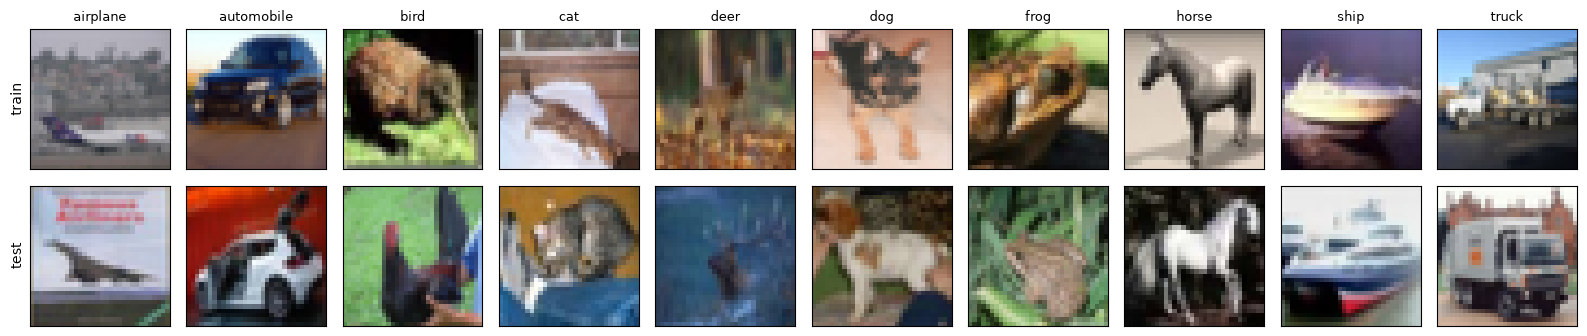

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(16, 3.6))
for c in range(10):
    for r, (x, y, part) in enumerate([(xtr, ytr, "train"), (xte, yte, "test")]):
        i = int(np.flatnonzero(y.numpy() == c)[0])
        axes[r, c].imshow(x[i].permute(1, 2, 0).numpy()); axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title(CLASSES[c], fontsize=9)
        if c == 0:
            axes[r, c].set_ylabel(part, fontsize=10)
plt.tight_layout(); savefig(fig, "task4_cifar10_examples"); plt.show()